In [2]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.ticker as ticker
import torchvision

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)


class CNN_Model(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = torch.nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = torch.nn.GroupNorm(8, 32)
        self.act1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2)

        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = torch.nn.GroupNorm(8, 64) 
        self.act2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2)

        self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = torch.nn.GroupNorm(8, 128) 
        self.act3 = torch.nn.ReLU()
        self.pool3 = torch.nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = torch.nn.Linear(128, 100)
        self.act4 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(100, 10)

    def forward(self, x):
        y = self.act1(self.bn1(self.conv1(x)))
        y = self.pool1(y)

        y = self.act2(self.bn2(self.conv2(y)))
        y = self.pool2(y)

        y = self.act3(self.bn3(self.conv3(y)))
        y = self.pool3(y)

        y = torch.flatten(y, 1)
        y = self.act4(self.fc1(y))
        y = self.fc2(y)
        return y     

In [5]:
SEED = 42
set_seed(SEED)
BATCH_SIZE = 1

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 0)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 0)

LEARNING_RATE = 0.001
EPOCHS = 500

In [6]:
ROOT_DIR = "outputs/CIFAR10_CNN"
TARGET_DIR = f"{ROOT_DIR}/{LEARNING_RATE}/{BATCH_SIZE}/{EPOCHS}/{SEED}"
os.makedirs(TARGET_DIR, exist_ok=True)

# SGD

In [7]:
SGD_DIR = f"{TARGET_DIR}/SGD"
os.makedirs(SGD_DIR, exist_ok=True)

if not os.path.exists(f"{SGD_DIR}/result.json"):
    set_seed(SEED)
    model = CNN_Model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr = LEARNING_RATE)

    SGD_train_loss_history = []
    SGD_test_loss_history = []
    SGD_train_acc_history = []
    SGD_test_acc_history = []
    SGD_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0
        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(Y, T)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        fg_count += 1
        train_loss /= len(train_loader)
        train_acc = correct / total

        SGD_x.append(fg_count)
        SGD_train_loss_history.append(train_loss)
        SGD_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)
            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = criterion(Y, T)

                test_loss += loss.item()

                pred = Y.argmax(dim=1)
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        test_loss /= len(test_loader)
        test_acc = correct / total

        SGD_test_loss_history.append(test_loss)
        SGD_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        if fg_count >= EPOCHS:
            break
    
    os.makedirs(SGD_DIR, exist_ok=True)

    with open(f"{SGD_DIR}/result.json", "w") as f:
        json.dump({
            "train_loss": SGD_train_loss_history,
            "train_acc": SGD_train_acc_history,
            "test_loss": SGD_test_loss_history,
            "test_acc": SGD_test_acc_history,
            "x": SGD_x
        }, f, indent = 4)

epoch: 1


100%|██████████| 10000/10000 [00:15<00:00, 660.17it/s, loss=0.268, acc=0.432]


Train Loss: 1.7219, Acc: 0.3469 | Test Loss: 1.5497, Acc: 0.4325
epoch: 2


100%|██████████| 10000/10000 [00:19<00:00, 522.55it/s, loss=0.146, acc=0.555]


Train Loss: 1.3573, Acc: 0.4993 | Test Loss: 1.2247, Acc: 0.5551
epoch: 3


...

Train Loss: 0.0001, Acc: 1.0000 | Test Loss: 1.7378, Acc: 0.7921
epoch: 499


100%|██████████| 10000/10000 [00:17<00:00, 564.89it/s, loss=0, acc=0.792]      


Train Loss: 0.0001, Acc: 1.0000 | Test Loss: 1.7383, Acc: 0.7925
epoch: 500


100%|██████████| 10000/10000 [00:17<00:00, 586.86it/s, loss=0, acc=0.792]      

Train Loss: 0.0001, Acc: 1.0000 | Test Loss: 1.7385, Acc: 0.7922


# SVRG

In [8]:
set_seed(SEED)
class SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def calc_full_grads(self, model, dataloader, loss_func):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state["z"] = torch.zeros_like(p)
                state['hat_w'] = torch.clone(p)

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            loss = loss_func(Y, T) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue


                    grad = p.grad.detach()
                    state = self.state[p]
                    state["z"].add_(grad)

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["z"].div_(total_data)


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_w"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["w"])
                    if p.grad is None:
                        continue
                    state["snapshot_grad"] = torch.clone(p.grad.detach())


    @torch.no_grad()
    def step(self, closure=None):
        loss = None

        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                z = state['z']
                snapshot_grad = state["snapshot_grad"]
                v = grad - snapshot_grad + z
                p.sub_(v, alpha = lr)

        return loss

In [9]:
SVRG_DIR = f"{TARGET_DIR}/SVRG"
os.makedirs(SVRG_DIR, exist_ok=True)

if not os.path.exists(f"{SVRG_DIR}/result.json"):
    set_seed(SEED)
    model = CNN_Model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = SVRG(model.parameters(), lr = LEARNING_RATE)

    SVRG_train_loss_history = []
    SVRG_test_loss_history = []
    SVRG_train_acc_history = []
    SVRG_test_acc_history = []
    SVRG_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0

        optimizer.calc_full_grads(model, train_loader, criterion)
        fg_count += 1

        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.calc_snapshot_grads(model, X, T, criterion)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(Y, T)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        fg_count += 2
        train_loss /= len(train_loader)
        train_acc = correct / total

        SVRG_x.append(fg_count)
        SVRG_train_loss_history.append(train_loss)
        SVRG_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)
            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = criterion(Y, T)

                test_loss += loss.item()

                pred = Y.argmax(dim=1)
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        test_loss /= len(test_loader)
        test_acc = correct / total

        SVRG_test_loss_history.append(test_loss)
        SVRG_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        if fg_count >= EPOCHS:
            break

    with open(f"{SVRG_DIR}/result.json", "w") as f:
        json.dump({
            "train_loss": SVRG_train_loss_history,
            "train_acc": SVRG_train_acc_history,
            "test_loss": SVRG_test_loss_history,
            "test_acc": SVRG_test_acc_history,
            "x": SVRG_x
        }, f, indent = 4)

epoch: 1


100%|██████████| 10000/10000 [00:16<00:00, 593.55it/s, loss=0.334, acc=0.477]


Train Loss: 1.6945, Acc: 0.3668 | Test Loss: 1.4393, Acc: 0.4768
epoch: 2


100%|██████████| 10000/10000 [00:16<00:00, 606.13it/s, loss=0.061, acc=0.56] 


Train Loss: 1.2322, Acc: 0.5523 | Test Loss: 1.1867, Acc: 0.5603
epoch: 3


...

Train Loss: 0.0008, Acc: 1.0000 | Test Loss: 1.2424, Acc: 0.7949
epoch: 166


100%|██████████| 10000/10000 [00:18<00:00, 547.78it/s, loss=0.000118, acc=0.795]


Train Loss: 0.0008, Acc: 1.0000 | Test Loss: 1.2432, Acc: 0.7950
epoch: 167


100%|██████████| 10000/10000 [00:17<00:00, 576.75it/s, loss=0.000117, acc=0.795]

Train Loss: 0.0008, Acc: 1.0000 | Test Loss: 1.2439, Acc: 0.7949


# No Full Grad SVRG

In [10]:
set_seed(SEED)
class NFG_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["hat_a"] = torch.zeros_like(p)
                    state['hat_w'] = torch.clone(p)

                state["a"].zero_()
                state["t"] = 0


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_w"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["snapshot_grad"] = torch.clone(p.grad.detach())
                    p.copy_(state["w"])


    def end_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                state["hat_a"].copy_(state["a"])
                state['hat_w'] = torch.clone(p).detach()


    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                a = state['a']
                hat_a = state["hat_a"]
                snapshot_grad = state["snapshot_grad"]
                t = state["t"]

                v = grad - snapshot_grad + hat_a
                p.sub_(v, alpha = lr)
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))

                state["t"] += 1

        return loss

In [11]:
NFG_SVRG_DIR = f"{TARGET_DIR}/NFG_SVRG"
os.makedirs(NFG_SVRG_DIR, exist_ok=True)

if not os.path.exists(f"{NFG_SVRG_DIR}/result.json"):
    set_seed(SEED)
    model = CNN_Model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = NFG_SVRG(model.parameters(), lr = LEARNING_RATE)

    NFG_SVRG_train_loss_history = []
    NFG_SVRG_test_loss_history = []
    NFG_SVRG_train_acc_history = []
    NFG_SVRG_test_acc_history = []
    NFG_SVRG_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0

        optimizer.init_epoch()

        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.calc_snapshot_grads(model, X, T, criterion)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(Y, T)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        optimizer.end_epoch()

        fg_count += 2
        train_loss /= len(train_loader)
        train_acc = correct / total

        NFG_SVRG_x.append(fg_count)
        NFG_SVRG_train_loss_history.append(train_loss)
        NFG_SVRG_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)
            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = criterion(Y, T)

                test_loss += loss.item()

                pred = Y.argmax(dim=1)
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        test_loss /= len(test_loader)
        test_acc = correct / total

        NFG_SVRG_test_loss_history.append(test_loss)
        NFG_SVRG_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        if fg_count >= EPOCHS:
            break

    os.makedirs(NFG_SVRG_DIR, exist_ok=True)

    with open(f"{NFG_SVRG_DIR}/result.json", "w") as f:
        json.dump({
            "train_loss": NFG_SVRG_train_loss_history,
            "train_acc": NFG_SVRG_train_acc_history,
            "test_loss": NFG_SVRG_test_loss_history,
            "test_acc": NFG_SVRG_test_acc_history,
            "x": NFG_SVRG_x
        }, f, indent = 4)

epoch: 1


100%|██████████| 10000/10000 [00:17<00:00, 574.22it/s, loss=2.41, acc=0.0986]


Train Loss: 2.3201, Acc: 0.0986 | Test Loss: 2.3203, Acc: 0.0986
epoch: 2


100%|██████████| 10000/10000 [00:16<00:00, 603.59it/s, loss=0.303, acc=0.48] 


Train Loss: 1.7061, Acc: 0.3572 | Test Loss: 1.4360, Acc: 0.4802
epoch: 3


...

Train Loss: 2.3026, Acc: 0.1000 | Test Loss: 2.3026, Acc: 0.1000
epoch: 249


100%|██████████| 10000/10000 [00:16<00:00, 602.07it/s, loss=2.3, acc=0.1]  


Train Loss: 2.3026, Acc: 0.1000 | Test Loss: 2.3026, Acc: 0.1000
epoch: 250


100%|██████████| 10000/10000 [00:16<00:00, 593.33it/s, loss=2.3, acc=0.1]  

Train Loss: 2.3026, Acc: 0.1000 | Test Loss: 2.3026, Acc: 0.1000


# ASAI-SVRG

In [12]:
set_seed(SEED)
class ASAI_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["hat_a"] = torch.zeros_like(p)
                    state["z"] = torch.clone(p.detach())
                    state["hat_z"] = torch.clone(p.detach())

                state["a"].zero_()
                state["z"].zero_()
                state["t"] = 0


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_z"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["snapshot_grad"] = torch.clone(p.grad.detach())
                    p.copy_(state["w"])


    def end_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                state["hat_a"].copy_(state["a"])
                state['hat_z'].copy_(state["z"])


    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                a = state['a']
                prev_a = state["hat_a"]
                prev_grad = state["snapshot_grad"]
                z = state["z"]
                t = state["t"]

                v = grad - prev_grad + prev_a
                p.sub_(v, alpha = lr)
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))
                z.mul_(t / (t+1)).add_(p, alpha = 1 / (t+1))

                state["t"] += 1

        return loss

In [13]:
ASAI_SVRG_DIR = f"{TARGET_DIR}/ASAI_SVRG"
os.makedirs(ASAI_SVRG_DIR, exist_ok=True)

if not os.path.exists(f"{ASAI_SVRG_DIR}/result.json"):
    set_seed(SEED)
    model = CNN_Model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = ASAI_SVRG(model.parameters(), lr = LEARNING_RATE)

    ASAI_SVRG_train_loss_history = []
    ASAI_SVRG_test_loss_history = []
    ASAI_SVRG_train_acc_history = []
    ASAI_SVRG_test_acc_history = []
    ASAI_SVRG_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0

        optimizer.init_epoch()

        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.calc_snapshot_grads(model, X, T, criterion)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(Y, T)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        optimizer.end_epoch()

        fg_count += 2
        train_loss /= len(train_loader)
        train_acc = correct / total

        ASAI_SVRG_x.append(fg_count)
        ASAI_SVRG_train_loss_history.append(train_loss)
        ASAI_SVRG_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)

            backup = []
            with torch.no_grad():
                for group in optimizer.param_groups:
                    for p in group['params']:
                        state = optimizer.state[p]
                        backup.append(p.clone())
                        p.copy_(state["z"])

            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = criterion(Y, T)

                test_loss += loss.item()

                pred = Y.argmax(dim=1)
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

            with torch.no_grad():
                i = 0
                for group in optimizer.param_groups:
                    for p in group['params']:
                        p.copy_(backup[i])
                        i += 1

        test_loss /= len(test_loader)
        test_acc = correct / total

        ASAI_SVRG_test_loss_history.append(test_loss)
        ASAI_SVRG_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        if fg_count >= EPOCHS:
            break

    with open(f"{ASAI_SVRG_DIR}/result.json", "w") as f:
        json.dump({
            "train_loss": ASAI_SVRG_train_loss_history,
            "train_acc": ASAI_SVRG_train_acc_history,
            "test_loss": ASAI_SVRG_test_loss_history,
            "test_acc": ASAI_SVRG_test_acc_history,
            "x": ASAI_SVRG_x
        }, f, indent = 4)

epoch: 1


100%|██████████| 10000/10000 [00:16<00:00, 623.96it/s, loss=2.41, acc=0.0986]


Train Loss: 2.3201, Acc: 0.0986 | Test Loss: 2.3203, Acc: 0.0986
epoch: 2


100%|██████████| 10000/10000 [00:16<00:00, 599.55it/s, loss=1.14, acc=0.427]


Train Loss: 1.7034, Acc: 0.3586 | Test Loss: 1.5853, Acc: 0.4274
epoch: 3


...

Train Loss: 2.3026, Acc: 0.1000 | Test Loss: 2.3026, Acc: 0.1000
epoch: 249


100%|██████████| 10000/10000 [00:16<00:00, 603.45it/s, loss=2.3, acc=0.1]  


Train Loss: 2.3026, Acc: 0.1000 | Test Loss: 2.3026, Acc: 0.1000
epoch: 250


100%|██████████| 10000/10000 [00:18<00:00, 542.98it/s, loss=2.3, acc=0.1]  

Train Loss: 2.3026, Acc: 0.1000 | Test Loss: 2.3026, Acc: 0.1000


# Polyak Full Grad SVRG

In [14]:
set_seed(SEED)
class Polyak_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def calc_full_grads(self, model, dataloader, loss_func):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state["z"] = torch.zeros_like(p)
                state['hat_w'] = torch.clone(p)

                if "x" not in state:
                    state["x"] = torch.clone(p.detach())
                    state["hat_x"] = torch.clone(p.detach())

                state["x"].zero_()
                state["t"] = 0

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            loss = loss_func(Y, T) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue


                    grad = p.grad.detach()
                    state = self.state[p]
                    state["z"].add_(grad)

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["z"].div_(total_data)


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_w"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["w"])
                    if p.grad is None:
                        continue
                    state["snapshot_grad"] = torch.clone(p.grad.detach())


    def end_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                state['hat_x'].copy_(state["x"])


    @torch.no_grad()
    def step(self, closure=None):
        loss = None

        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                z = state['z']
                x = state["x"]
                t = state["t"]
                snapshot_grad = state["snapshot_grad"]
                v = grad - snapshot_grad + z
                p.sub_(v, alpha = lr)
                x.mul_(t / (t+1)).add_(p, alpha = 1 / (t+1))

                state["t"] += 1

        return loss

In [ ]:
Polyak_SVRG_DIR = f"{TARGET_DIR}/Polyak_SVRG"
os.makedirs(Polyak_SVRG_DIR, exist_ok=True)

if not os.path.exists(f"{Polyak_SVRG_DIR}/result.json"):
    set_seed(SEED)    
    model = CNN_Model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = Polyak_SVRG(model.parameters(), lr = LEARNING_RATE)

    Polyak_SVRG_train_loss_history = []
    Polyak_SVRG_test_loss_history = []
    Polyak_SVRG_train_acc_history = []
    Polyak_SVRG_test_acc_history = []
    Polyak_SVRG_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0

        optimizer.calc_full_grads(model, train_loader, criterion)
        fg_count += 1

        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.calc_snapshot_grads(model, X, T, criterion)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(Y, T)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})
        
        optimizer.end_epoch()

        fg_count += 2
        train_loss /= len(train_loader)
        train_acc = correct / total

        Polyak_SVRG_x.append(fg_count)
        Polyak_SVRG_train_loss_history.append(train_loss)
        Polyak_SVRG_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)

            backup = []
            with torch.no_grad():
                for group in optimizer.param_groups:
                    for p in group['params']:
                        state = optimizer.state[p]
                        backup.append(p.clone())
                        p.copy_(state["x"])

            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = criterion(Y, T)

                test_loss += loss.item()

                pred = Y.argmax(dim=1)
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

            with torch.no_grad():
                i = 0
                for group in optimizer.param_groups:
                    for p in group['params']:
                        p.copy_(backup[i])
                        i += 1

        test_loss /= len(test_loader)
        test_acc = correct / total

        Polyak_SVRG_test_loss_history.append(test_loss)
        Polyak_SVRG_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        if fg_count >= EPOCHS:
            break

    os.makedirs(Polyak_SVRG_DIR, exist_ok=True)

    with open(f"{Polyak_SVRG_DIR}/result.json", "w") as f:
        json.dump({
            "train_loss": Polyak_SVRG_train_loss_history,
            "train_acc": Polyak_SVRG_train_acc_history,
            "test_loss": Polyak_SVRG_test_loss_history,
            "test_acc": Polyak_SVRG_test_acc_history,
            "x": Polyak_SVRG_x
        }, f, indent = 4)

epoch: 1


100%|██████████| 10000/10000 [00:16<00:00, 612.00it/s, loss=1.01, acc=0.436]


Train Loss: 1.6945, Acc: 0.3668 | Test Loss: 1.5702, Acc: 0.4357
epoch: 2


100%|██████████| 10000/10000 [00:17<00:00, 586.59it/s, loss=0.113, acc=0.578]


Train Loss: 1.2322, Acc: 0.5523 | Test Loss: 1.1635, Acc: 0.5781
epoch: 3


...

100%|██████████| 10000/10000 [00:18<00:00, 536.56it/s, loss=0.00179, acc=0.806]


Train Loss: 0.2403, Acc: 0.9121 | Test Loss: 0.6804, Acc: 0.8057
epoch: 54


100%|██████████| 10000/10000 [00:18<00:00, 536.09it/s, loss=0.00523, acc=0.804]


Train Loss: 0.2699, Acc: 0.9021 | Test Loss: 0.6679, Acc: 0.8039
epoch: 55


 93%|█████████▎| 46404/50000 [05:13<00:22, 163.37it/s, loss=0.00155, acc=0.927] 

# GD

In [ ]:
set_seed(SEED)
class GD(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def calc_full_grads(self, model, dataloader, loss_func):
        model.train()
        self.zero_grad()
        train_loss, correct, total = 0, 0, 0
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = loss_func(Y, T) * len(X)

            loss.backward()

            train_loss += loss.item()
            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += len(X)
        
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue
                    p.grad.div_(total)
                
        train_loss /= total
        train_acc = correct / total

        return train_loss, train_acc


    @torch.no_grad()
    def step(self, closure=None):
        loss = None

        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                p.sub_(p.grad, alpha = lr)

        return loss

In [ ]:
GD_DIR = f"{TARGET_DIR}/GD"
os.makedirs(GD_DIR, exist_ok=True)

if not os.path.exists(f"{GD_DIR}/result.json"):
    set_seed(SEED)
    model = CNN_Model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = GD(model.parameters(), lr = LEARNING_RATE)

    GD_train_loss_history = []
    GD_test_loss_history = []
    GD_train_acc_history = []
    GD_test_acc_history = []
    GD_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()

        train_loss, train_acc = optimizer.calc_full_grads(model, train_loader, criterion)
        fg_count += 1
        optimizer.step()

        GD_train_loss_history.append(train_loss)
        GD_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X, T in test_loader:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = criterion(Y, T)

                test_loss += loss.item()

                pred = Y.argmax(dim=1)
                correct += (pred == T).sum().item()
                total += T.size(0)

        test_loss /= len(test_loader)
        test_acc = correct / total

        GD_test_loss_history.append(test_loss)
        GD_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        if fg_count >= EPOCHS:
            break

    os.makedirs(GD_DIR, exist_ok=True)

    with open(f"{GD_DIR}/result.json", "w") as f:
        json.dump({
            "train_loss": GD_train_loss_history,
            "train_acc": GD_train_acc_history,
            "test_loss": GD_test_loss_history,
            "test_acc": GD_test_acc_history,
            "x": GD_x
        }, f, indent = 4)

# 結果

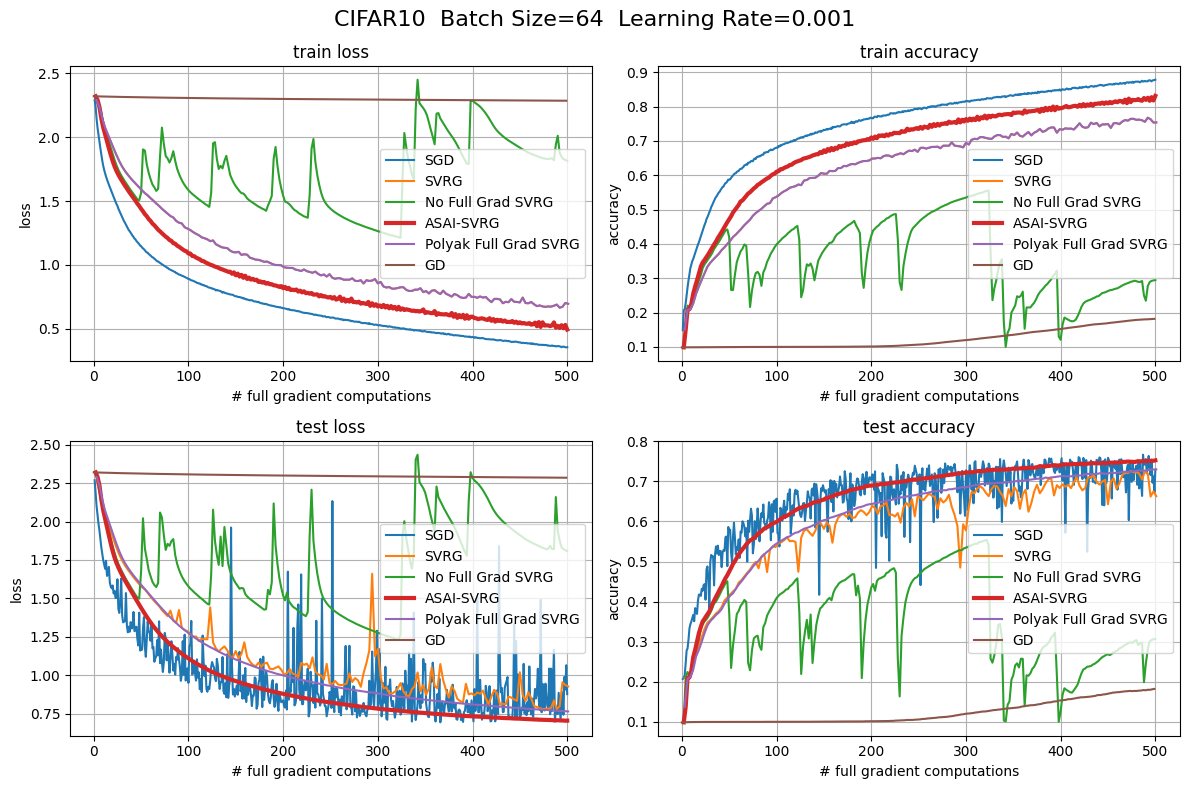

In [ ]:
import os
import json
import matplotlib.pyplot as plt

# 設定パラメータ（学習時と同じものを指定）
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 500
SEED = 42

TARGET_DIR = f"outputs/CIFAR10_CNN/{LEARNING_RATE}/{BATCH_SIZE}/{EPOCHS}/{SEED}"

# 1. データを読み込むための関数を定義
def load_result(optimizer_name):
    file_path = f"{TARGET_DIR}/{optimizer_name}/result.json"
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} が見つかりません。空のリストを返します。")
        # ファイルがない場合はプロット時にエラーにならないよう空リストを返す
        return [], [], [], [], []
    
    with open(file_path, "r") as f:
        data = json.load(f)
    
    return data["x"], data["train_loss"], data["train_acc"], data["test_loss"], data["test_acc"]

# 2. 各手法のJSONファイルを読み込み、変数に展開する
# SGD
SGD_x, SGD_train_loss_history, SGD_train_acc_history, SGD_test_loss_history, SGD_test_acc_history = load_result("SGD")

# SVRG
SVRG_x, SVRG_train_loss_history, SVRG_train_acc_history, SVRG_test_loss_history, SVRG_test_acc_history = load_result("SVRG")

# NFG_SVRG
NFG_SVRG_x, NFG_SVRG_train_loss_history, NFG_SVRG_train_acc_history, NFG_SVRG_test_loss_history, NFG_SVRG_test_acc_history = load_result("NFG_SVRG")

# ASAI_SVRG
ASAI_SVRG_x, ASAI_SVRG_train_loss_history, ASAI_SVRG_train_acc_history, ASAI_SVRG_test_loss_history, ASAI_SVRG_test_acc_history = load_result("ASAI_SVRG")

# Polyak_SVRG
Polyak_SVRG_x, Polyak_SVRG_train_loss_history, Polyak_SVRG_train_acc_history, Polyak_SVRG_test_loss_history, Polyak_SVRG_test_acc_history = load_result("Polyak_SVRG")

# GD (GDはx軸が異なる等の理由でxがない場合を想定し、_で受けて無視するか、適宜修正してください)
_, GD_train_loss_history, GD_train_acc_history, GD_test_loss_history, GD_test_acc_history = load_result("GD")


# 3. ご提示いただいたコードでプロットを実行
fig = plt.figure(figsize = (12, 8))
fig.suptitle(f"CIFAR10  Batch Size={BATCH_SIZE}  Learning Rate={LEARNING_RATE}",fontsize=16)

# --- Train Loss ---
ax = fig.add_subplot(2, 2, 1)
if SGD_x: ax.plot(SGD_x, SGD_train_loss_history, label = "SGD")
if SVRG_x: ax.plot(SVRG_x, SVRG_train_loss_history, label = "SVRG")
if NFG_SVRG_x: ax.plot(NFG_SVRG_x, NFG_SVRG_train_loss_history, label = "No Full Grad SVRG")
if ASAI_SVRG_x: ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_loss_history, label = "ASAI-SVRG", linewidth = 3)
if Polyak_SVRG_x: ax.plot(Polyak_SVRG_x, Polyak_SVRG_train_loss_history, label = "Polyak Full Grad SVRG")
if GD_train_loss_history: ax.plot(GD_train_loss_history, label = "GD") # GD用のx軸がある場合は追加してください
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.grid()
ax.legend()

# --- Train Accuracy ---
ax = fig.add_subplot(2, 2, 2)
if SGD_x: ax.plot(SGD_x, SGD_train_acc_history, label = "SGD")
if SVRG_x: ax.plot(SVRG_x, SVRG_train_acc_history, label = "SVRG")
if NFG_SVRG_x: ax.plot(NFG_SVRG_x, NFG_SVRG_train_acc_history, label = "No Full Grad SVRG")
if ASAI_SVRG_x: ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_acc_history, label = "ASAI-SVRG", linewidth = 3)
if Polyak_SVRG_x: ax.plot(Polyak_SVRG_x, Polyak_SVRG_train_acc_history, label = "Polyak Full Grad SVRG")
if GD_train_acc_history: ax.plot(GD_train_acc_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("train accuracy")
ax.grid()
ax.legend()

# --- Test Loss ---
ax = fig.add_subplot(2, 2, 3)
if SGD_x: ax.plot(SGD_x, SGD_test_loss_history, label = "SGD")
if SVRG_x: ax.plot(SVRG_x, SVRG_test_loss_history, label = "SVRG")
if NFG_SVRG_x: ax.plot(NFG_SVRG_x, NFG_SVRG_test_loss_history, label = "No Full Grad SVRG")
if ASAI_SVRG_x: ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_loss_history, label = "ASAI-SVRG", linewidth = 3)
if Polyak_SVRG_x: ax.plot(Polyak_SVRG_x, Polyak_SVRG_test_loss_history, label = "Polyak Full Grad SVRG")
if GD_test_loss_history: ax.plot(GD_test_loss_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.grid()
ax.legend()

# --- Test Accuracy ---
ax = fig.add_subplot(2, 2, 4)
if SGD_x: ax.plot(SGD_x, SGD_test_acc_history, label = "SGD")
if SVRG_x: ax.plot(SVRG_x, SVRG_test_acc_history, label = "SVRG")
if NFG_SVRG_x: ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG")
if ASAI_SVRG_x: ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_acc_history, label = "ASAI-SVRG", linewidth = 3)
if Polyak_SVRG_x: ax.plot(Polyak_SVRG_x, Polyak_SVRG_test_acc_history, label = "Polyak Full Grad SVRG")
if GD_test_acc_history: ax.plot(GD_test_acc_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

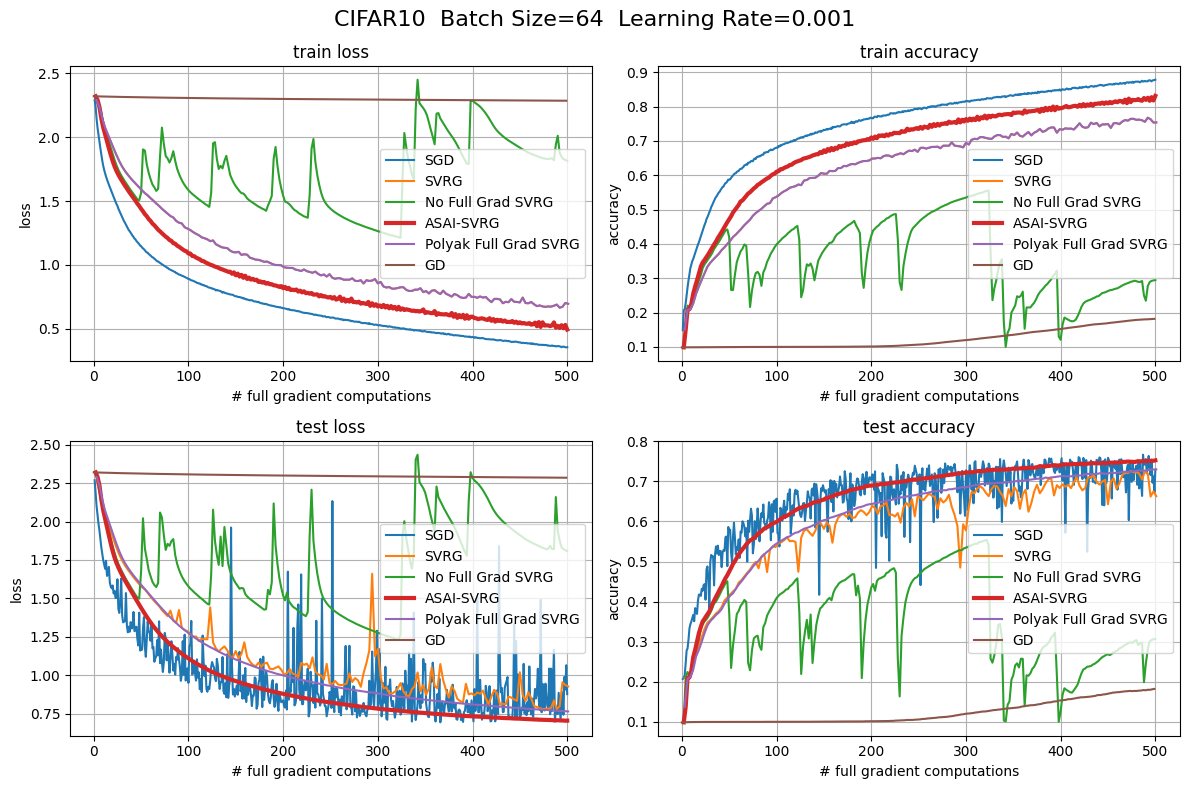

In [ ]:
fig = plt.figure(figsize = (12, 8))
fig.suptitle(f"CIFAR10  Batch Size={BATCH_SIZE}  Learning Rate={LEARNING_RATE}",fontsize=16)
ax = fig.add_subplot(2, 2, 1)
ax.plot(SGD_x, SGD_train_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_train_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_train_loss_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_loss_history, label = "ASAI-SVRG", linewidth = 3)
ax.plot(Polyak_SVRG_x, Polyak_SVRG_train_loss_history, label = "Polyak Full Grad SVRG")
ax.plot(GD_train_loss_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 2)
ax.plot(SGD_x, SGD_train_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_train_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_train_acc_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_acc_history, label = "ASAI-SVRG", linewidth = 3)
ax.plot(Polyak_SVRG_x, Polyak_SVRG_train_acc_history, label = "Polyak Full Grad SVRG")
ax.plot(GD_train_acc_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("train accuracy")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 3)
ax.plot(SGD_x, SGD_test_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_loss_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_loss_history, label = "ASAI-SVRG", linewidth = 3)
ax.plot(Polyak_SVRG_x, Polyak_SVRG_test_loss_history, label = "Polyak Full Grad SVRG")
ax.plot(GD_test_loss_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 4)
ax.plot(SGD_x, SGD_test_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_acc_history, label = "ASAI-SVRG", linewidth = 3)
ax.plot(Polyak_SVRG_x, Polyak_SVRG_test_acc_history, label = "Polyak Full Grad SVRG")
ax.plot(GD_test_acc_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

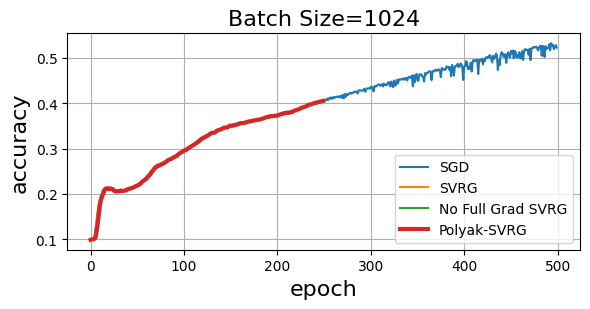

In [ ]:
fig = plt.figure(figsize = (6, 3.2))
ax = fig.add_subplot()
ax.plot(SGD_x, SGD_test_acc_history, label = "SGD")
ax.plot(SVRG_test_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_test_acc_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_test_acc_history, label = "Polyak-SVRG", linewidth = 3)
ax.set_xlabel("epoch", fontsize=16)
ax.set_ylabel("accuracy", fontsize=16)
ax.set_title(f"Batch Size={BATCH_SIZE}" ,fontsize=16)
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

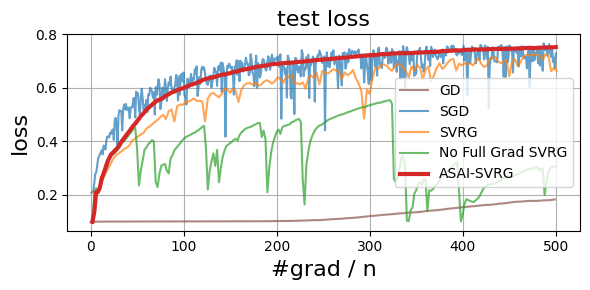

In [ ]:
fig = plt.figure(figsize = (6, 3))
ax = fig.add_subplot()
ax.plot(GD_test_acc_history, label = "GD", c = 'tab:brown', alpha = 0.7)
ax.plot(SGD_x, SGD_test_acc_history, label = "SGD", c = 'tab:blue', alpha = 0.7)
ax.plot(SVRG_x, SVRG_test_acc_history, label = "SVRG", c = 'tab:orange', alpha = 0.7)
ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG", c = 'tab:green', alpha = 0.7)
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_acc_history, label = "ASAI-SVRG", linewidth = 3, c = 'tab:red')
ax.set_xlabel("#grad / n", fontsize=16)
ax.set_ylabel("loss", fontsize=16)
ax.set_title('test loss' ,fontsize=16)
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()